In [1]:
!pip install --upgrade pip
!pip install torch tqdm numpy scikit-learn

import os, numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# clone datasets (or reuse your existing)
!rm -rf /content/datasets
!git clone https://github.com/CSTCloudOps/datasets.git /content/datasets

allinone = "/content/datasets/MTS/SWaT/AllInOne"
train = np.load(os.path.join(allinone, "train.npy")).astype(np.float32)   # (N,F)
test  = np.load(os.path.join(allinone, "test.npy")).astype(np.float32)    # (M,F)
test_label = np.load(os.path.join(allinone, "test_label.npy")).astype(int)

print("train:", train.shape, "test:", test.shape, "test_label:", test_label.shape)
F = train.shape[1]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Cloning into '/content/datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 26.30 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
train: (473399, 51) test: (449919, 51) test_label: (449919,)


In [2]:
class WindowDataset(Dataset):
    def __init__(self, x2d: np.ndarray, window: int):
        self.x = x2d
        self.w = window

    def __len__(self):
        return max(len(self.x) - self.w + 1, 0)

    def __getitem__(self, i):
        # return (T,F)
        return torch.from_numpy(self.x[i:i+self.w])

WINDOW = 96
BATCH = 256
train_loader = DataLoader(WindowDataset(train, WINDOW), batch_size=BATCH, shuffle=True, drop_last=True)
test_loader  = DataLoader(WindowDataset(test,  WINDOW), batch_size=BATCH, shuffle=False)

print("train batches:", len(train_loader), "test batches:", len(test_loader))

train batches: 1848 test batches: 1758


In [3]:
import torch.nn as nn
from tqdm import tqdm

class TCNEncoder(nn.Module):
    def __init__(self, n_features: int, d_model: int = 64, emb_dim: int = 64):
        super().__init__()
        # (B,T,F) -> (B,F,T) for Conv1d
        self.net = nn.Sequential(
            nn.Conv1d(n_features, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # (B,d_model,1)
        )
        self.proj = nn.Linear(d_model, emb_dim)

    def forward(self, x):
        # x: (B,T,F)
        x = x.transpose(1,2)          # (B,F,T)
        h = self.net(x).squeeze(-1)   # (B,d_model)
        z = self.proj(h)              # (B,emb_dim)
        return z

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = TCNEncoder(n_features=F, d_model=64, emb_dim=64).to(device)
print("Device:", device)

Device: cpu


DeepSVDD training (center c + minimize distance)

In [4]:
import torch.optim as optim

EPOCHS = 30
LR = 1e-3

opt = optim.Adam(encoder.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

# 1) compute center c from one pass (no grad)
encoder.eval()
with torch.no_grad():
    zs = []
    for X in tqdm(train_loader, desc="Compute center c"):
        X = X.to(device)
        z = encoder(X)
        zs.append(z)
    Z = torch.cat(zs, dim=0)
    c = Z.mean(dim=0)                       # (emb_dim,)
    # avoid tiny values (standard DeepSVDD trick)
    c[(c.abs() < 1e-6)] = 1e-6

c = c.detach()
print("Center c shape:", c.shape)

# 2) train to minimize ||z - c||^2
encoder.train()
for ep in range(1, EPOCHS+1):
    encoder.train()
    loss_sum = 0.0
    for X in tqdm(train_loader, desc=f"Train {ep}/{EPOCHS}"):
        X = X.to(device)
        opt.zero_grad()
        z = encoder(X)
        loss = ((z - c)**2).sum(dim=1).mean()
        loss.backward()
        opt.step()
        loss_sum += loss.detach().item()

    scheduler.step()
    print(f"Epoch {ep}: loss={loss_sum/max(len(train_loader),1):.6f}")

torch.save({"encoder": encoder.state_dict(), "c": c.cpu().numpy()}, "deepsvdd_swat.pt")
print("Saved: deepsvdd_swat.pt")

Compute center c: 100%|██████████| 1848/1848 [01:03<00:00, 29.01it/s]


Center c shape: torch.Size([64])


Train 1/30: 100%|██████████| 1848/1848 [02:20<00:00, 13.11it/s]


Epoch 1: loss=0.000067


Train 2/30: 100%|██████████| 1848/1848 [02:22<00:00, 12.97it/s]


...

Epoch 28: loss=0.000000


Train 29/30: 100%|██████████| 1848/1848 [02:29<00:00, 12.33it/s]


Epoch 29: loss=0.000000


Train 30/30: 100%|██████████| 1848/1848 [02:30<00:00, 12.31it/s]

Epoch 30: loss=0.000000
Saved: deepsvdd_swat.pt


Inference: anomaly score per window + align labels

In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import numpy as np
import torch
from tqdm import tqdm

ckpt = torch.load("deepsvdd_swat.pt", map_location=device, weights_only=False)
encoder.load_state_dict(ckpt["encoder"])
c = torch.tensor(ckpt["c"], device=device)

encoder.eval()
scores = []
with torch.no_grad():
    for X in tqdm(test_loader, desc="Test scoring"):
        X = X.to(device)
        z = encoder(X)
        s = ((z - c)**2).sum(dim=1)   # (B,)
        scores.append(s.detach().cpu())

scores = torch.cat(scores, dim=0).numpy().astype(np.float64)
scores[np.isnan(scores)] = 1000
print("scores len:", len(scores))

y_true = test_label[-len(scores):].astype(int)
print("y_true len:", len(y_true), "attack ratio:", y_true.mean())

Test scoring: 100%|██████████| 1758/1758 [01:13<00:00, 23.94it/s]

scores len: 449824
y_true len: 449824 attack ratio: 0.12142749164117521


Metrics (same style as KANAD notebook)

In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import numpy as np

auc = roc_auc_score(y_true, scores)
ap  = average_precision_score(y_true, scores)

precision, recall, thresholds = precision_recall_curve(y_true, scores)
f1 = 2*(precision*recall)/(precision+recall+1e-8)
best_idx = np.argmax(f1)
best_f1 = f1[best_idx]
best_th = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

print("=== DeepSVDD (SWaT) ===")
print("ROC-AUC:", auc)
print("PR-AUC :", ap)
print("Best F1:", best_f1)
print("Best threshold:", best_th)

=== DeepSVDD (SWaT) ===
ROC-AUC: 0.8367956392824993
PR-AUC : 0.7534520907101621
Best F1: 0.7573632806897709
Best threshold: 0.00011670518142636865


Optional smoothing (often helps SWaT)

In [10]:
def moving_average(x, w=9):
    return np.convolve(x, np.ones(w)/w, mode="same")

scores_s = moving_average(scores, w=9)

auc_s = roc_auc_score(y_true, scores_s)
ap_s  = average_precision_score(y_true, scores_s)

p, r, th = precision_recall_curve(y_true, scores_s)
f1_s = 2*(p*r)/(p+r+1e-8)
best_f1_s = f1_s.max()

print("=== DeepSVDD (SWaT) with smoothing w=9 ===")
print("ROC-AUC:", auc_s)
print("PR-AUC :", ap_s)
print("Best F1:", best_f1_s)

=== DeepSVDD (SWaT) with smoothing w=9 ===
ROC-AUC: 0.8356445922577391
PR-AUC : 0.7536820590098845
Best F1: 0.7573663430405277


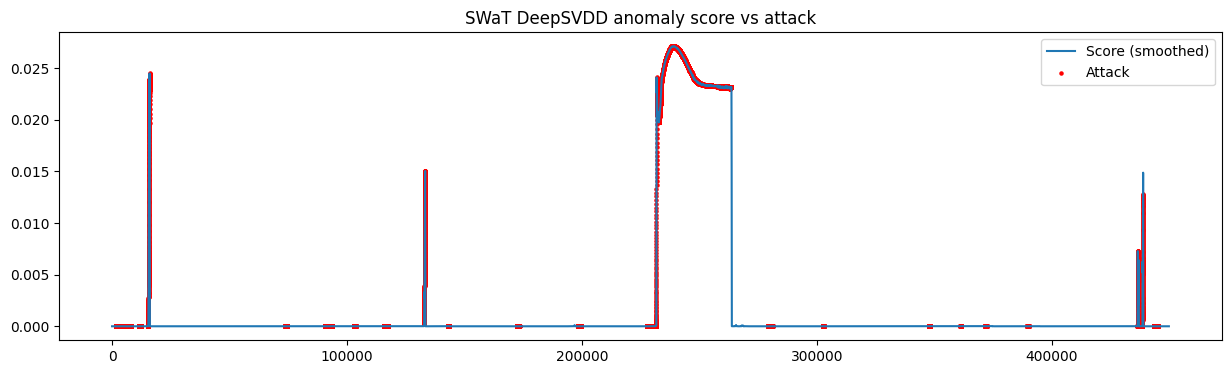

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(scores_s, label="Score (smoothed)" if "scores_s" in globals() else "Score")
attack_idx = np.where(y_true == 1)[0]
plt.scatter(attack_idx, (scores_s if "scores_s" in globals() else scores)[attack_idx],
            s=5, color="red", label="Attack")
plt.title("SWaT DeepSVDD anomaly score vs attack")
plt.legend()
plt.show()